In [ ]:
import helpers
import importlib
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1.0,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2.0,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3.0,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4.0,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5.0,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [ ]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
CaseManager = helpers.CaseManager

groups = {
    "Explicit Euler QUICK": CaseManager([16,17,18,19,20], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="quick", RE=1000),
    "Explicit Euler UDS": CaseManager([31,34,33,32, 35, 36,37], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000),
    # "AB2": CaseManager([21,22,23,24,25], solution_method="EFSM", time_scheme=2, N=64, conv_scheme="quick", RE=1000),
    "SIMPLE": CaseManager([28], solution_method="simple", N=64, conv_scheme="uds", RE=1000)
}



In [ ]:
# groups["EFSM Explicit Euler"].compare_meta()
groups["Explicit Euler QUICK"].compare_meta().sort_values(by='DT').reset_index()

,index,solution_method,conv_scheme,RE,N,time_scheme,DT,clock_time,IT,sum_N,total_outer_iterations,total_inner_iterations,avg_inner_per_outer
0,20,fs,quick,1000.0,64,1,0.0005,76.141212,63517,3617,63517,72340,1.138908
1,19,fs,quick,1000.0,64,1,0.0010,47.817623,35260,2668,35260,53360,1.513330
2,18,fs,quick,1000.0,64,1,0.0050,34.663536,9328,6445,9328,128900,13.818611
3,17,fs,quick,1000.0,64,1,0.0100,48.560310,5552,10979,5552,219580,39.549712
4,16,fs,quick,1000.0,64,1,0.0150,61.849926,4202,14547,4202,290940,69.238458


In [96]:
groups["AB2"].compare_meta().sort_values(by='DT').reset_index()[['DT', 'IT']]-groups["Explicit Euler QUICK"].compare_meta().sort_values(by='DT').reset_index()[['DT', 'IT']]

,DT,IT
0,0.0,-17
1,0.0,2
2,0.0,11
3,0.0,-1
4,0.0,-12


In [ ]:
SIMPLE_groups = { "SIMPLE": CaseManager([28], solution_method="simple", N=64, conv_scheme="uds", RE=1000)}

In [ ]:
EFSM_groups = {
    # "Explicit Euler QUICK": CaseManager([16,17,18,19,20], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="quick", RE=1000),
    # "Explicit Euler UDS": CaseManager([31,34,33,32, 35, 36,37, 38, 39], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000),
    "Explicit Euler UDS": CaseManager([31,34,33,32, 35, 36,37, 38, 39,40,41,42,43,44,45,46], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000),
}

In [133]:
EFSM_groups["Explicit Euler UDS"].compare_meta().sort_values(by='DT')

,solution_method,conv_scheme,RE,N,time_scheme,DT,clock_time,IT,sum_N,total_outer_iterations,total_inner_iterations,avg_inner_per_outer
35,fs,uds,1000.0,64,2,0.00050,74.731491,53406,3958,53406,79160,1.482230
36,fs,uds,1000.0,64,2,0.00075,59.427193,38422,4749,38422,94980,2.472021
33,fs,uds,1000.0,64,2,0.00500,77.035553,8051,11446,8051,228920,28.433735
38,fs,uds,1000.0,64,2,0.00750,95.118500,5759,29406,5759,588120,102.121896
34,fs,uds,1000.0,64,2,0.01000,113.239769,4530,30347,4530,606940,133.982340
32,fs,uds,1000.0,64,2,0.01000,113.157005,4530,30347,4530,606940,133.982340
37,fs,uds,1000.0,64,2,0.01250,128.216080,3717,34444,3717,688880,185.332257
39,fs,uds,1000.0,64,2,0.01500,140.862259,3102,37346,3102,746920,240.786589
31,fs,uds,1000.0,64,2,0.01700,152.181244,4500,39540,4500,790800,175.733333


Explicit Euler UDS


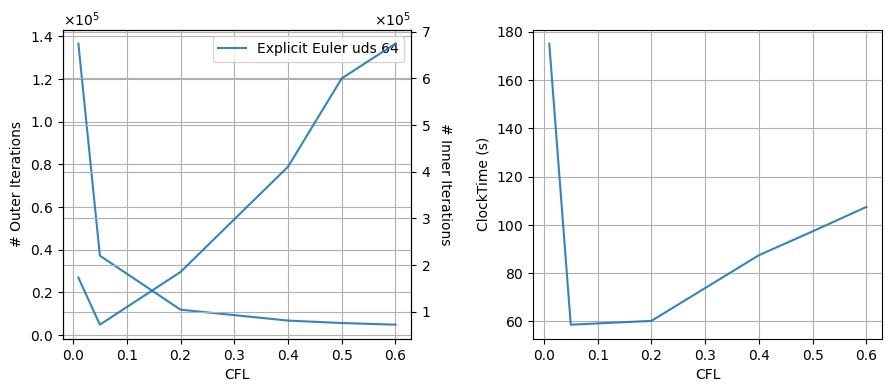

In [167]:

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
time_scheme_dict = {
    1: "Explicit Euler",
    2: "AB2"
}
labels = ["Explicit Euler","AB2"]
ax0_copy=axes[0].twinx()
for i,(group_name, group) in enumerate(EFSM_groups.items()):
    print(group_name)
    meta_df =  group.compare_meta()
    solver=group.solution_method.upper()
    label = f"{time_scheme_dict[group.time_scheme]} {group.conv_scheme} {group.N}"
    DX = 1/meta_df['N']
    lw=1.5
    meta_df['CFL']=meta_df['DT']/DX
    meta_df = meta_df.sort_values(by='CFL') 
    axes[0].plot(meta_df['CFL'], meta_df["IT"], label=label, alpha=0.9, linewidth=lw)
    ax0_copy.plot(meta_df['CFL'], meta_df["total_inner_iterations"], label=label, alpha=0.9, linewidth=lw)
    axes[1].plot(meta_df['CFL'], meta_df["clock_time"], label=label, alpha=0.9, linewidth=lw)
    
    
for ax in [axes[0], axes[1], ax0_copy]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)

axes[0].set_ylabel("# Outer Iterations")
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

axes[0].legend()
axes[0].set_xlabel("CFL")
# axes[0].set_title("Clock Time (s)")
ax0_copy.set_ylabel("# Inner Iterations", rotation=270, labelpad=15)
ax0_copy.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel("ClockTime (s)")
axes[1].set_xlabel("CFL")
# axes[1].set_title("SIMPLE")
# axes[0].set_ylim(3202, 5202)
fig.tight_layout(pad=1)  # still useful for general spacing
fig.subplots_adjust(wspace=0.35) 

Explicit Euler QUICK
Explicit Euler UDS
SIMPLE
Convergence dataframe is empty!


/var/folders/dz/13jyqy9s2pj6nzzr5q4x48nw0000gn/T/ipykernel_60439/730237982.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, 'SIMPLE')

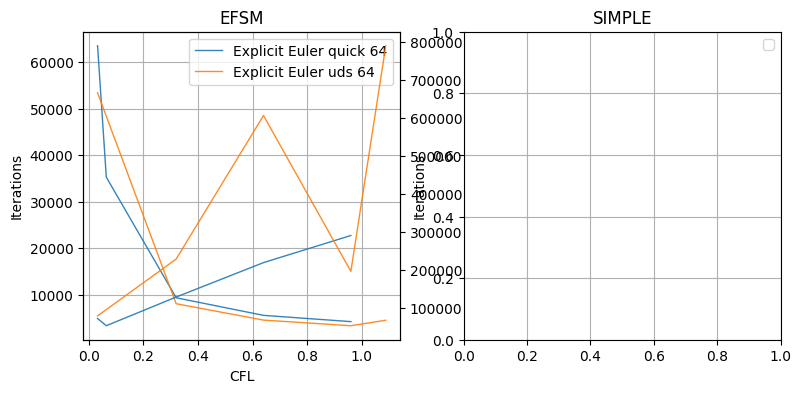

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
time_scheme_dict = {
    1: "Explicit Euler",
    2: "AB2"
}
labels = ["Explicit Euler","AB2"]
ax0_copy=axes[0].twinx()
for i,(group_name, group) in enumerate(groups.items()):
    print(group_name)
    meta_df =  group.compare_meta()
    solver=group.solution_method.upper()
    if i>1:
        break
    if solver == "EFSM":
        ax=axes[0]
        label = f"{time_scheme_dict[group.time_scheme]} {group.conv_scheme} {group.N}"
        DX = 1/meta_df['N']
        lw=1
        meta_df['CFL']=meta_df['DT']/DX
        meta_df = meta_df.sort_values(by='CFL')
        
        ax.plot(meta_df['CFL'], meta_df["IT"], label=label, alpha=0.9, linewidth=lw)
        ax0_copy.plot(meta_df['CFL'], meta_df["total_inner_iterations"], label=label, alpha=0.9, linewidth=lw)
    elif solver== "SIMPLE":
        ax=axes[1]
        label = f"{group.conv_scheme} {group.N}"
    else: 
        print("no solution method")

    
for ax in axes:
    ax.set_ylabel("Iterations")
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend()
axes[0].set_xlabel("CFL")
axes[0].set_title("EFSM")
axes[1].set_title("SIMPLE")
# axes[0].set_ylim(3202, 5202)


In [62]:
case=CavityCase(20)
case.meta

{'solution_method': 'fs',
 'conv_scheme': 'quick',
 'RE': 1000.0,
 'N': 64,
 'time_scheme': 1,
 'DT': 0.000500000024,
 'clock_time': 76.1412125,
 'IT': np.int64(63517)}